In [2]:
import re
import shutil
import glob
import pandas as pd
from pathlib import Path

In [3]:
# Paths
BASE_DIR        = Path(r"c:\Users\Usuario\Documents\Monroe County ORRI")

SOURCE_OH       = BASE_DIR / "UltimateFiles"              # OH... folders (exact name match)
SOURCE_BOOKPAGE = BASE_DIR / "UTIC files (book-page)"     # MONROE-BOOK-PAGE folders
DEST_DIR        = BASE_DIR / "Deal Files"                  # output

EXCEL_FILE      = glob.glob(str(BASE_DIR / "*FLAT*.xlsx"))[0]
AGREEMENTS_FILE = BASE_DIR / "AgreementsExtractedTables" / "All_Agreements_Combined.xlsx"

BPO_FILE        = BASE_DIR / "CLEAN DATA BPO (1).xlsx"
DEAL_FILES_ORIG = BASE_DIR / "Deal Files Original"


print(f"Excel file      : {EXCEL_FILE}")
print(f"Source OH       : {SOURCE_OH}")
print(f"Source Book-Page: {SOURCE_BOOKPAGE}")
print(f"Destination     : {DEST_DIR}")
print(f"Agreements_Files   : {AGREEMENTS_FILE}")

Excel file      : c:\Users\Usuario\Documents\Monroe County ORRI\Monroe County ORRI — Project Log FLATRIVER.xlsx
Source OH       : c:\Users\Usuario\Documents\Monroe County ORRI\UltimateFiles
Source Book-Page: c:\Users\Usuario\Documents\Monroe County ORRI\UTIC files (book-page)
Destination     : c:\Users\Usuario\Documents\Monroe County ORRI\Deal Files
Agreements_Files   : c:\Users\Usuario\Documents\Monroe County ORRI\AgreementsExtractedTables\All_Agreements_Combined.xlsx


In [ ]:
# Load Deal Name data from two sources and merge (BPO takes priority)

COL_DEAL   = "DEAL NAME"
COL_LEASE  = "Heritage Lease Name"
COL_SELLER = "SELLER"

# --- FLATRIVER (DB FINDING sheet) ---
df_flat_raw = pd.read_excel(EXCEL_FILE, sheet_name="DB FINDING", header=0)
df_flat = df_flat_raw[[COL_DEAL, COL_LEASE, COL_SELLER]].dropna(subset=[COL_DEAL, COL_LEASE]).copy()
df_flat[COL_DEAL]   = df_flat[COL_DEAL].astype(str).str.strip()
df_flat[COL_LEASE]  = df_flat[COL_LEASE].astype(str).str.strip()
df_flat[COL_SELLER] = df_flat[COL_SELLER].fillna("").astype(str).str.strip()
df_flat = df_flat.drop_duplicates(subset=[COL_LEASE], keep="first")

# --- CLEAN DATA BPO (primary / preferred source) ---
df_bpo_raw = pd.read_excel(BPO_FILE, sheet_name="DATA", header=0, usecols=[0, 7])
df_bpo_raw.columns = [COL_LEASE, COL_DEAL]
df_bpo = df_bpo_raw.dropna(subset=[COL_DEAL, COL_LEASE]).copy()
df_bpo[COL_DEAL]   = df_bpo[COL_DEAL].astype(str).str.strip()
df_bpo[COL_LEASE]  = df_bpo[COL_LEASE].astype(str).str.strip()
df_bpo[COL_SELLER] = ""  # BPO has no seller column
df_bpo = df_bpo.drop_duplicates(subset=[COL_LEASE], keep="first")

# --- Merge: BPO first so drop_duplicates keeps BPO values ---
merged  = pd.concat([df_bpo, df_flat], ignore_index=True)
mapping = merged.drop_duplicates(subset=[COL_LEASE], keep="first").reset_index(drop=True)

bpo_leases = set(df_bpo[COL_LEASE])
flat_only  = mapping[~mapping[COL_LEASE].isin(bpo_leases)]
print(f"BPO leases       : {len(df_bpo)}")
print(f"FLATRIVER leases : {len(df_flat)}")
print(f"Combined (unique): {len(mapping)}  ({len(mapping) - len(flat_only)} from BPO, {len(flat_only)} FLATRIVER-only)")

oh_count     = mapping[COL_LEASE].str.upper().str.startswith("OH").sum()
monroe_count = mapping[COL_LEASE].str.upper().str.startswith("MONROE").sum()
umd_count    = mapping[COL_LEASE].str.upper().str.startswith("UMD").sum()
other_count  = len(mapping) - oh_count - monroe_count - umd_count
print(f"OH entries    : {oh_count}")
print(f"MONROE entries: {monroe_count}")
print(f"UMD entries   : {umd_count}  (no matching folder, will be skipped)")
print(f"Other entries : {other_count}")

# Load agreements mapping: Lease No. -> [Source File, ...]
try:
    agreements_df = pd.read_excel(AGREEMENTS_FILE)
    lease_to_sources = agreements_df.groupby("Lease No.")["Source File"].unique().to_dict()
    print(f"Loaded {len(lease_to_sources)} unique lease mappings from Agreements file.")
except FileNotFoundError:
    print(f"Warning: Agreements file not found at {AGREEMENTS_FILE}")
    lease_to_sources = {}


In [ ]:
# Resolve each Heritage Lease Name to a source folder path
def sanitize_name(name):
    """Remove characters invalid in Windows folder names and flatten newlines."""
    name = str(name)
    # 1. Replace newlines, carriage returns, and tabs with a single space
    name = re.sub(r'[\r\n\t]', ' ', name)
    # 2. Replace invalid Windows path characters with a hyphen
    name = re.sub(r'[\/:*?"<>|]', '-', name)
    # 3. Collapse any accidental double spaces and strip trailing whitespace
    name = re.sub(r'\s+', ' ', name).strip()
    return name

def find_source_folder(lease_name):
    """
    OH...    -> match in UltimateFiles/:
               Priority 1: folder with __UTIC_files_(renamed)__ in name
               Priority 2: exact name match (no suffix)
               Priority 3: any other variant (e.g. ___HG_ORRI_)
    MONROE-BOOK-PAGE -> look for BOOK-PAGE in UTIC files (book-page)/
    UMD...   -> no folder, return None
    """
    upper = lease_name.upper()

    if upper.startswith("OH"):
        # Priority 1: __UTIC_files_(renamed)__ variant
        utic_matches = [
            p for p in SOURCE_OH.iterdir()
            if p.is_dir()
            and p.name.startswith(lease_name)
            and '__UTIC_files_(renamed)__' in p.name
        ]
        if utic_matches:
            return utic_matches[0]
        # Priority 2: exact match (no suffix)
        candidate = SOURCE_OH / lease_name
        if candidate.exists() and candidate.is_dir():
            return candidate
        # Priority 3: any other variant
        others = [
            p for p in SOURCE_OH.iterdir()
            if p.is_dir() and p.name.startswith(lease_name)
        ]
        return others[0] if others else None

    if upper.startswith("MONROE-"):
        # Extract BOOK-PAGE: MONROE-143-110 -> 143-110
        m = re.search(r'MONROE-(.+)', lease_name, re.IGNORECASE)
        if m:
            book_page = m.group(1).strip()
            candidate = SOURCE_BOOKPAGE / book_page
            if candidate.exists() and candidate.is_dir():
                return candidate
        return None

    return None   # UMD or other - no folder

# Test resolution on the mapping
mapping = mapping.copy()
mapping["source_path"] = mapping[COL_LEASE].apply(find_source_folder)
mapping["found"] = mapping["source_path"].notna()

print(f"Folders found   : {mapping['found'].sum()} / {len(mapping)}")
print(f"Not found       : {(~mapping['found']).sum()}")
print()
print("Not found entries:")
print(mapping[~mapping["found"]][[COL_LEASE, COL_DEAL]].to_string(index=False))


Folders found   : 222 / 226
Not found       : 4

Not found entries:
        Heritage Lease Name         DEAL NAME
MONROE-51-453 (OH00369-00))   Howell 4.1.1907
MONROE-174-384 (OH00277-00)  Howell 8.22.2008
 MONROE-45-602 (OH00433-00) Howell 10.28.1903
  MONROE-47-57 (OH00434-00)  Howell 12.5.1904


In [ ]:
# Compare Deal Files Original subfolders against Excel files man (expected 17)
AGREEMENTS_DIR = BASE_DIR / "AgreementsExtractedTables" / "Excel files man"

excel_folders = {
    sanitize_name(x.stem)
    for x in AGREEMENTS_DIR.glob("*.xlsx")
    if not x.name.startswith("~$")
}

if DEAL_FILES_ORIG.exists():
    orig_folders = {p.name for p in DEAL_FILES_ORIG.iterdir() if p.is_dir()}
else:
    orig_folders = set()
    print(f"Deal Files Original not found at: {DEAL_FILES_ORIG}")

missing_from_orig = excel_folders - orig_folders
extra_in_orig     = orig_folders - excel_folders - {"Uncategorized"}

print(f"Expected agreement folders (from Excel files man): {len(excel_folders)}")
print(f"Folders in Deal Files Original                   : {len(orig_folders)}")
print()
if missing_from_orig:
    print("MISSING from Deal Files Original (will be created in new run):")
    for f in sorted(missing_from_orig):
        print(f"  - {f}")
else:
    print("All expected folders present in Deal Files Original.")
if extra_in_orig:
    print("Extra folders in Deal Files Original (not in Excel files man):")
    for f in sorted(extra_in_orig):
        print(f"  + {f}")


In [ ]:
# Copy matched folders into Deal Files/, renamed by Deal Name and grouped by Source File
AGREEMENTS_FILE = BASE_DIR / "AgreementsExtractedTables" / "All_Agreements_Combined.xlsx"

# 1. Load the agreements file to map Leases to their respective Source Files (subfolders)
try:
    agreements_df = pd.read_excel(AGREEMENTS_FILE)
    # Group by Lease No. to handle leases that appear in multiple Source Files
    lease_to_sources = agreements_df.groupby("Lease No.")["Source File"].unique().to_dict()
    print(f"Loaded {len(lease_to_sources)} unique lease mappings from Agreements file.\n")
except FileNotFoundError:
    print(f"Warning: Agreements file not found at {AGREEMENTS_FILE}\n")
    lease_to_sources = {}

# 2. Clear out the old Deal Files directory
if DEST_DIR.exists():
    print(f"Removing existing: {DEST_DIR}")
    shutil.rmtree(DEST_DIR)
DEST_DIR.mkdir()

# Pre-create ALL agreement subfolders (so none are missing even if empty)
AGREEMENTS_DIR = BASE_DIR / "AgreementsExtractedTables" / "Excel files man"
for xlsx in sorted(AGREEMENTS_DIR.glob("*.xlsx")):
    if not xlsx.name.startswith("~$"):
        (DEST_DIR / sanitize_name(xlsx.stem)).mkdir(exist_ok=True)
print(f"Pre-created agreement subfolders from: {AGREEMENTS_DIR.name}")

# Track duplicates PER subfolder: seen_dest_names[subfolder][deal_name]
seen_dest_names = {}   
copied_count = 0

for _, row in mapping[mapping["found"]].iterrows():
    lease_name  = row[COL_LEASE]
    deal_name   = sanitize_name(row[COL_DEAL])
    src_path    = row["source_path"]

    # Get the subfolders for this lease, default to "Uncategorized" if not in the agreements file
    source_files = lease_to_sources.get(lease_name, ["Uncategorized"])

    for sf in source_files:
        sf_clean = sanitize_name(str(sf))
        subfolder_path = DEST_DIR / sf_clean
        subfolder_path.mkdir(exist_ok=True)
        
        if sf_clean not in seen_dest_names:
            seen_dest_names[sf_clean] = {}

        # Handle multiple leases mapping to the same Deal Name within THIS subfolder
        if deal_name in seen_dest_names[sf_clean]:
            seen_dest_names[sf_clean][deal_name] += 1
            dest_name = f"{deal_name}_{seen_dest_names[sf_clean][deal_name]}"
        else:
            seen_dest_names[sf_clean][deal_name] = 1
            dest_name = deal_name

        dest_path = subfolder_path / dest_name
        shutil.copytree(src_path, dest_path)
        copied_count += 1
        print(f"  [OK]   {lease_name} -> {sf_clean}/{dest_name}")

print(f"\nDone. {copied_count} folders copied across subfolders in '{DEST_DIR.name}'.")

Loaded 263 unique lease mappings from Agreements file.

Removing existing: c:\Users\Usuario\Documents\Monroe County ORRI\Deal Files
Pre-created agreement subfolders from: Excel files man
  [OK]   OH00149-02 -> AEU to AEUM_294_646/Whitacre Et Al 1.22.1919
  [OK]   OH00149-02 -> Whitacre to AEU_284_1/Whitacre Et Al 1.22.1919
  [OK]   OH00149-03 -> Whitacre to AEU_284_1/Whitacre Et Al 6.12.1919
  [OK]   OH00455-00 -> Kroll to AEUM_298_858/Kroll 1.2.1980
  [OK]   OH00156-00 -> AEU to AEUM_294_646/SS&B Petroleum, LLC 4.9.2004
  [OK]   OH00156-00 -> Byers to AEU_287-784/SS&B Petroleum, LLC 4.9.2004
  [OK]   OH00206-00 -> AEU to AEUM_294_646/Whitacre Et Al 10.15.2006
  [OK]   OH00206-00 -> Whitacre to AEU_284_1/Whitacre Et Al 10.15.2006
  [OK]   OH00203-00 -> AEU to AEUM_294_646/Whitacre Et Al 4.14.2010
  [OK]   OH00203-00 -> Whitacre to AEU_284_1/Whitacre Et Al 4.14.2010
  [OK]   OH00204-00 -> AEU to AEUM_294_646/Whitacre Et Al 7.26.2007
  [OK]   OH00204-00 -> Whitacre to AEU_284_1/Whitacre 

In [ ]:
# Final report – entries with no assigned folder
unmatched = mapping[~mapping["found"]][[COL_LEASE, COL_DEAL]].reset_index(drop=True)
unmatched.index += 1

print(f"Total unmatched entries: {len(unmatched)}\n")
print(unmatched.to_string())
unmatched

Total unmatched entries: 4

0          Heritage Lease Name          DEAL NAME
1  MONROE-51-453 (OH00369-00))    Howell 4.1.1907
2  MONROE-174-384 (OH00277-00)   Howell 8.22.2008
3   MONROE-45-602 (OH00433-00)  Howell 10.28.1903
4    MONROE-47-57 (OH00434-00)   Howell 12.5.1904


,Heritage Lease Name,DEAL NAME
1,MONROE-51-453 (OH00369-00)),Howell 4.1.1907
2,MONROE-174-384 (OH00277-00),Howell 8.22.2008
3,MONROE-45-602 (OH00433-00),Howell 10.28.1903
4,MONROE-47-57 (OH00434-00),Howell 12.5.1904


In [ ]:
# Unmatched entries excluding UMD
unmatched_no_umd = unmatched[~unmatched[COL_LEASE].str.upper().str.startswith("UMD")].reset_index(drop=True)
unmatched_no_umd.index += 1

print(f"Unmatched entries (excluding UMD): {len(unmatched_no_umd)}\n")
print(unmatched_no_umd.to_string())
unmatched_no_umd

Unmatched entries (excluding UMD): 4

0          Heritage Lease Name          DEAL NAME
1  MONROE-51-453 (OH00369-00))    Howell 4.1.1907
2  MONROE-174-384 (OH00277-00)   Howell 8.22.2008
3   MONROE-45-602 (OH00433-00)  Howell 10.28.1903
4    MONROE-47-57 (OH00434-00)   Howell 12.5.1904


,Heritage Lease Name,DEAL NAME
1,MONROE-51-453 (OH00369-00)),Howell 4.1.1907
2,MONROE-174-384 (OH00277-00),Howell 8.22.2008
3,MONROE-45-602 (OH00433-00),Howell 10.28.1903
4,MONROE-47-57 (OH00434-00),Howell 12.5.1904


In [ ]:
# For unmatched non-UMD entries, attempt fallback lookup using Column D (Book and Page combined) from DB FINDING
import re

# Reload full data from DB FINDING sheet. Headers are on the first row (header=0).
df_full = pd.read_excel(EXCEL_FILE, sheet_name="DB FINDING", header=0)

# Define columns. We use index 3 to guarantee we grab Column D regardless of its exact name
COL_DEAL = "DEAL NAME"
COL_LEASE = "Heritage Lease Name"
COL_BOOKPAGE = df_full.columns[3] # Column D

# Clean up dataframe
df_full = df_full[[COL_DEAL, COL_LEASE, COL_BOOKPAGE]].dropna(subset=[COL_DEAL, COL_LEASE])
df_full[COL_LEASE] = df_full[COL_LEASE].astype(str).str.strip()
df_full[COL_DEAL]  = df_full[COL_DEAL].astype(str).str.strip()
df_full = df_full.drop_duplicates(subset=[COL_LEASE], keep="first")

# Filter to the unmatched non-UMD lease names only
fallback_df = df_full[df_full[COL_LEASE].isin(unmatched_no_umd[COL_LEASE])].copy()

fallback_results = []

for _, row in fallback_df.iterrows():
    lease_name = row[COL_LEASE]
    deal_name  = sanitize_name(row[COL_DEAL])
    raw_bp     = row[COL_BOOKPAGE]

    folder_name = None
    
    # Parse the Book and Page from the combined string (e.g., "LR 143-110" or "208/358")
    if pd.notna(raw_bp):
        m = re.search(r'(\d+)\s*[-/\\|_]\s*(\d+)', str(raw_bp))
        if m:
            folder_name = f"{int(m.group(1))}-{int(m.group(2))}"

    if not folder_name:
        print(f"  [??]  {lease_name}  (no valid Book/Page found in Col D: '{raw_bp}', skipped)")
        fallback_results.append((lease_name, deal_name, None, "no Book/Page data"))
        continue

    candidate = SOURCE_BOOKPAGE / folder_name

    if candidate.exists() and candidate.is_dir():
        source_files = lease_to_sources.get(lease_name, ["Uncategorized"])
        
        for sf in source_files:
            sf_clean = sanitize_name(str(sf))
            subfolder_path = DEST_DIR / sf_clean
            subfolder_path.mkdir(exist_ok=True)
            
            if sf_clean not in seen_dest_names:
                seen_dest_names[sf_clean] = {}

            if deal_name in seen_dest_names[sf_clean]:
                seen_dest_names[sf_clean][deal_name] += 1
                dest_name = f"{deal_name}_{seen_dest_names[sf_clean][deal_name]}"
            else:
                seen_dest_names[sf_clean][deal_name] = 1
                dest_name = deal_name

            dest_path = subfolder_path / dest_name
            shutil.copytree(candidate, dest_path)
            print(f"  [OK]  {lease_name} -> {folder_name} -> {sf_clean}/{dest_name}")
            
        fallback_results.append((lease_name, deal_name, folder_name, "COPIED"))
    else:
        print(f"  [--]  {lease_name}  Book/Page={folder_name}  (folder not found in UTIC files (book-page))")
        fallback_results.append((lease_name, deal_name, folder_name, "folder not found"))

# Summary
fallback_summary = pd.DataFrame(fallback_results, columns=[COL_LEASE, COL_DEAL, "book_page_folder", "status"])
copied  = (fallback_summary["status"] == "COPIED").sum()
missing = (fallback_summary["status"] != "COPIED").sum()
print(f"\nFallback results: {copied} copied, {missing} still not found.")
fallback_summary

  [OK]  MONROE-51-453 (OH00369-00)) -> 51-453 -> Uncategorized/Howell 4.1.1907
  [OK]  MONROE-174-384 (OH00277-00) -> 174-384 -> Uncategorized/Howell 8.22.2008
  [OK]  MONROE-45-602 (OH00433-00) -> 45-602 -> Uncategorized/Howell 10.28.1903
  [OK]  MONROE-47-57 (OH00434-00) -> 47-57 -> Uncategorized/Howell 12.5.1904

Fallback results: 4 copied, 0 still not found.


,Heritage Lease Name,DEAL NAME,book_page_folder,status
0,MONROE-51-453 (OH00369-00)),Howell 4.1.1907,51-453,COPIED
1,MONROE-174-384 (OH00277-00),Howell 8.22.2008,174-384,COPIED
2,MONROE-45-602 (OH00433-00),Howell 10.28.1903,45-602,COPIED
3,MONROE-47-57 (OH00434-00),Howell 12.5.1904,47-57,COPIED


In [ ]:
# Search remaining unmatched entries in Located Leases/ by Book-Page PDF name
SOURCE_LOCATED = BASE_DIR / "Located Leases"

# Entries still not copied after the fallback
still_missing = fallback_summary[fallback_summary["status"] != "COPIED"][[COL_LEASE, COL_DEAL, "book_page_folder"]]

located_results = []

for _, row in still_missing.iterrows():
    lease_name = row[COL_LEASE]
    deal_name  = sanitize_name(row[COL_DEAL])
    book_page  = row["book_page_folder"]

    # If book_page was missing in the fallback step, try re-fetching from df_full column D
    if pd.isna(book_page) or book_page is None:
        match = df_full[df_full[COL_LEASE] == lease_name]
        if match.empty or pd.isna(match.iloc[0][COL_BOOKPAGE]):
            print(f"  [??]  {lease_name}  (no Book/Page available)")
            located_results.append((lease_name, deal_name, None, "no Book/Page data"))
            continue
            
        raw_bp = match.iloc[0][COL_BOOKPAGE]
        m = re.search(r'(\d+)\s*[-/\\|_]\s*(\d+)', str(raw_bp))
        if m:
            book_page = f"{int(m.group(1))}-{int(m.group(2))}"
        else:
            print(f"  [??]  {lease_name}  (no valid Book/Page format found: '{raw_bp}')")
            located_results.append((lease_name, deal_name, None, "no Book/Page data"))
            continue

    pdf_candidate = SOURCE_LOCATED / f"{book_page}.pdf"

    if pdf_candidate.exists():
        source_files = lease_to_sources.get(lease_name, ["Uncategorized"])
        
        for sf in source_files:
            sf_clean = sanitize_name(str(sf))
            subfolder_path = DEST_DIR / sf_clean
            subfolder_path.mkdir(exist_ok=True)
            
            if sf_clean not in seen_dest_names:
                seen_dest_names[sf_clean] = {}

            if deal_name in seen_dest_names[sf_clean]:
                seen_dest_names[sf_clean][deal_name] += 1
                dest_name = f"{deal_name}_{seen_dest_names[sf_clean][deal_name]}.pdf"
            else:
                seen_dest_names[sf_clean][deal_name] = 1
                dest_name = f"{deal_name}.pdf"

            dest_path = subfolder_path / dest_name
            shutil.copy2(pdf_candidate, dest_path)
            print(f"  [OK]  {lease_name} -> {book_page}.pdf -> {sf_clean}/{dest_name}")
            
        located_results.append((lease_name, deal_name, book_page, "COPIED"))
    else:
        print(f"  [--]  {lease_name}  Book/Page={book_page}  (not found in Located Leases)")
        located_results.append((lease_name, deal_name, book_page, "not found"))

located_summary = pd.DataFrame(located_results, columns=[COL_LEASE, COL_DEAL, "book_page", "status"])
copied  = (located_summary["status"] == "COPIED").sum()
missing = (located_summary["status"] != "COPIED").sum()
print(f"\nLocated Leases results: {copied} copied, {missing} still not found.")
located_summary


Located Leases results: 0 copied, 0 still not found.


,Heritage Lease Name,DEAL NAME,book_page,status


In [ ]:
# Final list of all entries not found across all three attempts
final_missing = located_summary[located_summary["status"] != "COPIED"][[COL_LEASE, COL_DEAL, "book_page", "status"]].reset_index(drop=True)
final_missing.index += 1

print(f"\nEntries with no assigned file or folder after all attempts: {len(final_missing)}")
print(final_missing.to_string())
final_missing


Entries with no assigned file or folder after all attempts: 0
Empty DataFrame
Columns: [Heritage Lease Name, DEAL NAME, book_page, status]
Index: []


,Heritage Lease Name,DEAL NAME,book_page,status


ASSIGNMENT REPORT BY DATA SOURCE
                 Total  Assigned  Not Assigned % Assigned
Source                                                   
BPO only            37        32             5      86.5%
Both (BPO wins)    210       210             0     100.0%
FLATRIVER only     112        45            67      40.2%

Grand total   : 359 leases
  Assigned    : 287
  Not assigned: 72

Unassigned leases:
   Heritage Lease Name                    DEAL NAME     data_source
1           OH00104-50                AEU 10.3.1915        BPO only
2           OH00278-00   Howell's O&G, LLC 4.5.1955        BPO only
3           OH00290-00  Howell's O&G, LLC 10.7.1918        BPO only
4           OH00348-00    Whitacre Et Al  5.10.1990        BPO only
5           OH00166-02    Whitacre Et Al  7.14.2006        BPO only
6           OH00403-00                    5.23.2011  FLATRIVER only
7           OH00483-00                    5.23.2011  FLATRIVER only
8       MONROE-143-110                     2.6

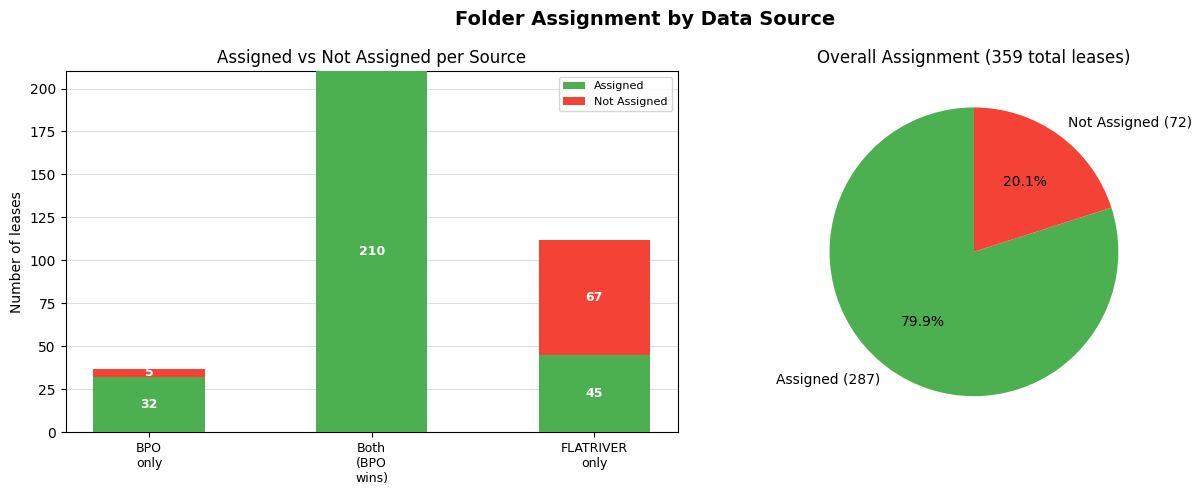

In [19]:
# Assignment Report: which rows from each source got a folder
import matplotlib.pyplot as plt
import numpy as np

# 1. Tag each row in mapping with its data source
bpo_set  = set(df_bpo[COL_LEASE])
flat_set = set(df_flat[COL_LEASE])

def row_source(lease):
    in_bpo  = lease in bpo_set
    in_flat = lease in flat_set
    if in_bpo and in_flat:
        return "Both (BPO wins)"
    elif in_bpo:
        return "BPO only"
    else:
        return "FLATRIVER only"

mapping_rep = mapping.copy()
mapping_rep["data_source"] = mapping_rep[COL_LEASE].apply(row_source)

# 2. Build final-assignment set across all three attempts
assigned_set = set(mapping_rep[mapping_rep["found"]][COL_LEASE])
try:
    assigned_set |= set(fallback_summary[fallback_summary["status"] == "COPIED"][COL_LEASE])
except NameError:
    pass
try:
    assigned_set |= set(located_summary[located_summary["status"] == "COPIED"][COL_LEASE])
except NameError:
    pass

mapping_rep["assigned"] = mapping_rep[COL_LEASE].isin(assigned_set)

# 3. Summary table
sources_order = ["BPO only", "Both (BPO wins)", "FLATRIVER only"]
rows = []
for src in sources_order:
    sub = mapping_rep[mapping_rep["data_source"] == src]
    if sub.empty:
        continue
    total        = len(sub)
    assigned     = int(sub["assigned"].sum())
    not_assigned = total - assigned
    rows.append({"Source": src, "Total": total,
                 "Assigned": assigned, "Not Assigned": not_assigned,
                 "% Assigned": f"{100 * assigned / total:.1f}%"})

summary_df = pd.DataFrame(rows).set_index("Source")
print("=" * 60)
print("ASSIGNMENT REPORT BY DATA SOURCE")
print("=" * 60)
print(summary_df.to_string())
print()
grand_total    = len(mapping_rep)
grand_assigned = int(mapping_rep["assigned"].sum())
print(f"Grand total   : {grand_total} leases")
print(f"  Assigned    : {grand_assigned}")
print(f"  Not assigned: {grand_total - grand_assigned}")

# 4. Detail table of unassigned rows
unassigned_detail = (mapping_rep[~mapping_rep["assigned"]]
                     [[COL_LEASE, COL_DEAL, "data_source"]]
                     .reset_index(drop=True))
unassigned_detail.index += 1
if len(unassigned_detail):
    print()
    print("Unassigned leases:")
    print(unassigned_detail.to_string())
else:
    print()
    print("All leases were assigned a folder.")

# 5. Chart (stacked bar per source + overall pie)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Folder Assignment by Data Source", fontsize=14, fontweight="bold")

src_labels        = [r["Source"]       for r in rows]
assigned_vals     = [r["Assigned"]     for r in rows]
not_assigned_vals = [r["Not Assigned"] for r in rows]
x     = np.arange(len(src_labels))
bar_w = 0.5

b1 = axes[0].bar(x, assigned_vals,     bar_w, label="Assigned",     color="#4CAF50", zorder=3)
b2 = axes[0].bar(x, not_assigned_vals, bar_w, label="Not Assigned", color="#F44336",
                 bottom=assigned_vals, zorder=3)

# Wrap long labels using chr(10) as newline
axes[0].set_xticks(x)
axes[0].set_xticklabels([s.replace(" ", chr(10)) for s in src_labels], fontsize=9)
axes[0].set_ylabel("Number of leases")
axes[0].set_title("Assigned vs Not Assigned per Source")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(axis="y", alpha=0.4, zorder=0)

for rect, val in zip(b1, assigned_vals):
    if val:
        axes[0].text(rect.get_x() + rect.get_width() / 2,
                     rect.get_y() + val / 2,
                     str(val), ha="center", va="center",
                     fontsize=9, color="white", fontweight="bold")
for rect, bot, val in zip(b2, assigned_vals, not_assigned_vals):
    if val:
        axes[0].text(rect.get_x() + rect.get_width() / 2,
                     bot + val / 2,
                     str(val), ha="center", va="center",
                     fontsize=9, color="white", fontweight="bold")

total_not = grand_total - grand_assigned
axes[1].pie(
    [grand_assigned, total_not],
    labels=[f"Assigned ({grand_assigned})", f"Not Assigned ({total_not})"],
    colors=["#4CAF50", "#F44336"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10}
)
axes[1].set_title(f"Overall Assignment ({grand_total} total leases)")

plt.tight_layout()
plt.show()


In [20]:
# Export assignment report to CSV
csv_path = BASE_DIR / "assignment_report.csv"

# Build full per-lease detail table
export_rows = []
for _, row in mapping_rep.iterrows():
    export_rows.append({
        "Heritage Lease Name": row[COL_LEASE],
        "Deal Name":           row[COL_DEAL],
        "Data Source":         row["data_source"],
        "Assigned":            "Yes" if row["assigned"] else "No",
    })

export_df = pd.DataFrame(export_rows)
export_df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"CSV saved: {csv_path}")
print(f"  Rows: {len(export_df)}  |  Assigned: {(export_df['Assigned']=='Yes').sum()}  |  Not assigned: {(export_df['Assigned']=='No').sum()}")
export_df


CSV saved: c:\Users\Usuario\Documents\Monroe County ORRI\assignment_report.csv
  Rows: 359  |  Assigned: 287  |  Not assigned: 72


,Heritage Lease Name,Deal Name,Data Source,Assigned
0,OH00176-00,Darrell R. Cline 8.1.1980,BPO only,Yes
1,OH00177-00,Darrell R Cline 12.16.1920,BPO only,Yes
2,OH00178-00,Darrell R. Cline 11.11.1981,BPO only,Yes
3,OH00236-00,Whitacre Et Al 5.12.1959,Both (BPO wins),Yes
4,OH00502-00,Whitacre Et Al 9.15.1967,Both (BPO wins),Yes
...,...,...,...,...
354,OH00168-00,12.1.1970,FLATRIVER only,No
355,OH-00168-01,2.18.1969,FLATRIVER only,No
356,OH-00169-00,2.17.1969,FLATRIVER only,No
357,OH00116-00,6.27.2011,FLATRIVER only,Yes
